# Symplectic Methods Exploration Notebook

From Hairer, Lubich, and Wanner we obtain the following differential equations,

\begin{align}
    \ddot{q} = f(q), \qquad f(q) = - \frac{q}{\|q\|^{3}}, \qquad q = (q_{1}, q_{2}) \in \mathbb{R}^2. \tag{2.2}
\end{align}

With $p = \dot q$, the Hamiltonian system is as follows,

\begin{align}
    H(p, q) = \tfrac12\left(p_1^2 + p_2^2\right) - \frac{1}{\sqrt{q_1^2 + q_2^2}}. \tag{2.3}
\end{align}

We choose the following initial conditions for the differential equations (2.2),
\begin{align}
    q_1\left(0\right) = 1 - e, \qquad q_2(0) = 0, \qquad \dot{q}_{1}(0) = 0, \qquad \dot{q}_{2}\left(0\right) = \sqrt{\frac{1+e}{1-e}}. \tag{2.11}
\end{align}


In [9]:
import numpy as np
import matplotlib.pyplot as plt

e = 0.6
q0 = np.array([1 - e, 0.0])
p0 = np.array([0.0, np.sqrt((1 + e) / (1 - e))])
H0 = -0.5
L0 = np.sqrt(1 - e**2)


**Numerical Methods**

Each method is a one-step map $\Phi_h : \left(q_n, p_n\right) \mapsto \left(q_{n+1}, p_{n+1}\right)$; with a step size of $h$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(q):
    return -q / np.hypot(q[0], q[1])**3 # eq. (2.2)

def H(qs, ps): # eq. (2.3)
    return 0.5*(ps**2).sum(axis=1) - 1/np.linalg.norm(qs, axis=1)

def L(qs, ps): # eq. (2.4)
    return qs[:, 0]*ps[:, 1] - qs[:, 1]*ps[:, 0]

def explicit_euler(q, p, h):
    return q + h*p, p + h*f(q)

def symplectic_euler(q, p, h): # eq (1.9)
    p = p + h*f(q)
    q = q + h*p
    return q, p

def stormer_verlet(q, p, h): # eq. (1.17)
    p = p + 0.5*h*f(q) 
    q = q + h*p
    p = p + 0.5*h*f(q)
    return q, p

num_iters = []

def implicit_midpoint(q, p, h, maxit=200):
    Q, P = explicit_euler(q, p, h) # initial guess
    d_old = np.inf
    for k in range(1, maxit + 1):
        q_n = q + h * 0.5 * (p + P)
        p_n = p + h * f(0.5 * (q + Q))
        d = np.sqrt(np.sum((q_n - Q)**2) + np.sum((p_n - P)**2))
        Q, P = q_n, p_n
        if d == 0 or d >= d_old: # updates stop shrinking
            num_iters.append(k)
            return Q, P
        d_old = d
    raise RuntimeError
    
def integrate(step, h, n):
    qs, ps = np.empty((n + 1, 2)), np.empty((n + 1, 2))
    qs[0], ps[0] = q0, p0
    for i in range(n):
        qs[i + 1], ps[i + 1] = step(qs[i], ps[i], h)
    return qs, ps



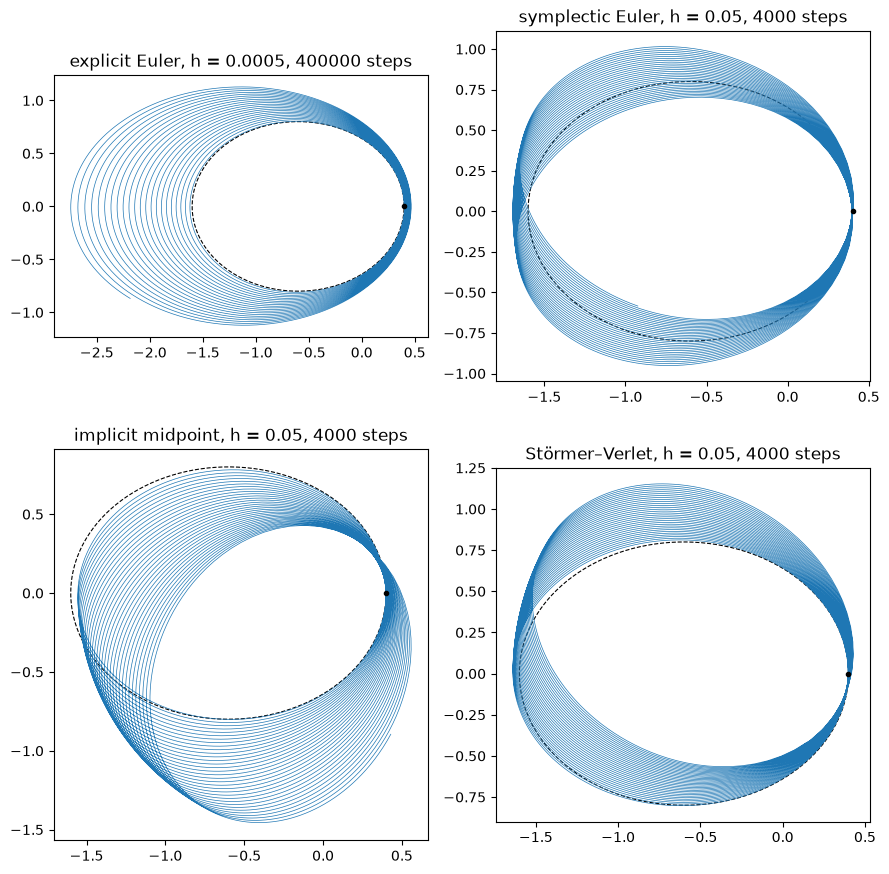

In [11]:
runs = {
    "explicit Euler":    (explicit_euler,    0.0005, 400_000),
    "symplectic Euler":  (symplectic_euler,  0.05,   4000),
    "implicit midpoint": (implicit_midpoint, 0.05,   4000),
    "Störmer–Verlet":    (stormer_verlet,    0.05,   4000),
}
num_iters.clear()
results = {name: integrate(step, h, n) for name, (step, h, n) in runs.items()}

E = np.linspace(0, 2*np.pi, 400)
exact = (np.cos(E) - e, np.sqrt(1 - e**2) * np.sin(E))  # exact orbit: a = 1, focus at origin

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (name, (qs, ps)) in zip(axes.flat, results.items()):
    _, h, n = runs[name]
    ax.plot(*exact, "k--", lw=0.8)
    ax.plot(qs[:, 0], qs[:, 1], lw=0.5)
    ax.plot(*q0, "ko", ms=3)
    ax.set_title(f"{name}, h = {h}, {n} steps")
    ax.set_aspect("equal")
fig.tight_layout()
